# Empirical Results: Figures and Tables


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'empirical' / 'results').exists(): 
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

RESULTS = ROOT / 'empirical' / 'results'
OUT = ROOT / 'empirical' / 'figures' / '05_thesis_figures'
OUT.mkdir(parents=True, exist_ok=True)

def load(split):
    base = pd.read_csv(RESULTS/'pto'/'pto_quarterly_pd_irb_predictions.csv', parse_dates=['date'])
    base = base.rename(columns={c: c.replace('_mlp', '_pto_mlp').replace('_linear', '_pto_linear').replace('_persistence', '_pto_persistence') for c in base.columns if c.startswith(('alpha_hat_', 'regret_', 'utility_', 'pd_q_hat_', 'pd_a_hat_', 'c_q_hat_', 'k_irb_hat_'))})
    for family in ['blackbox','dfl']:
        other = pd.read_csv(RESULTS/family/f'{family}_quarterly_pd_irb_predictions.csv', parse_dates=['date'])
        cols = ['date'] + [c for c in other.columns if c not in base.columns]
        base = base.merge(other[cols], on='date', how='inner')
    return base.sort_values('date')

data = {s:load(s) for s in ['stress']}

from minou_colours import MINOU_COLOURS
COLORS = {'pto_mlp':MINOU_COLOURS['teal'],'blackbox_mlp':MINOU_COLOURS['navy'],'dfl_mlp':MINOU_COLOURS['sage'],'oracle':MINOU_COLOURS['coral'],'persistence':MINOU_COLOURS['grey']}


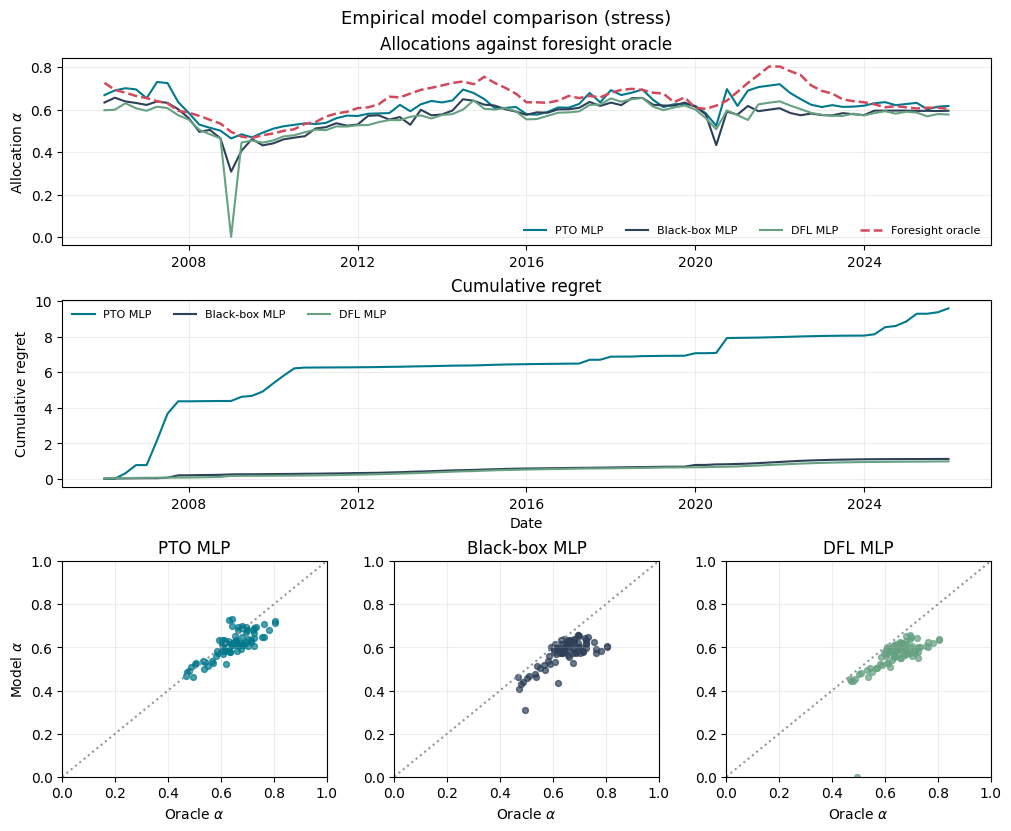

Saved empirical/figures/05_thesis_figures/stress_combined_model_comparison.png


In [ ]:
# Combined empirical comparison plot
for split, df in data.items():
    models = [('pto_mlp', 'PTO MLP'), ('blackbox_mlp', 'Black-box MLP'), ('dfl_mlp', 'DFL MLP')]
    fig = plt.figure(figsize=(10, 8.2), constrained_layout=True)
    gs = fig.add_gridspec(3, 3, height_ratios=[1.0, 1.0, 1.15])
    ax_alpha = fig.add_subplot(gs[0, :])
    ax_regret = fig.add_subplot(gs[1, :], sharex=ax_alpha)
    cal_axes = [fig.add_subplot(gs[2, i]) for i in range(3)]
    for m, label in models:
        if f'alpha_hat_{m}' in df:
            ax_alpha.plot(df['date'], df[f'alpha_hat_{m}'], color=COLORS[m], lw=1.5, label=label)
        if f'regret_{m}' in df:
            ax_regret.plot(df['date'], df[f'regret_{m}'].cumsum(), color=COLORS[m], lw=1.5, label=label)
    ax_alpha.plot(df['date'], df['alpha_oracle'], '--', color=COLORS['oracle'], lw=1.8, label='Foresight oracle')
    ax_alpha.set_ylabel(r'Allocation $\alpha$'); ax_alpha.set_title('Allocations against foresight oracle')
    ax_regret.set_ylabel('Cumulative regret'); ax_regret.set_xlabel('Date'); ax_regret.set_title('Cumulative regret')
    for ax in [ax_alpha, ax_regret]: ax.grid(alpha=.22); ax.legend(frameon=False, fontsize=8, ncol=4)
    for ax, (m, label) in zip(cal_axes, models):
        if f'alpha_hat_{m}' in df:
            ax.scatter(df['alpha_oracle'], df[f'alpha_hat_{m}'], s=18, alpha=.7, color=COLORS[m])
        ax.plot([0, 1], [0, 1], ':', color=MINOU_COLOURS['grey'])
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_title(label); ax.set_xlabel(r'Oracle $\alpha$'); ax.grid(alpha=.22)
    cal_axes[0].set_ylabel(r'Model $\alpha$')
    fig.suptitle(f'Empirical model comparison ({split})', fontsize=13)
    path = OUT / f'{split}_combined_model_comparison.png'
    fig.savefig(path, dpi=300, bbox_inches='tight'); plt.show()
    print(f'Saved {path.relative_to(ROOT)}')


In [ ]:
# Empirical out-of-sample decision-performance table.
# The thesis table uses the stress split.
TABLE_SPLIT = 'stress'
TABLE_MODELS = [
    ('pto', 'PTO'), ('dfl', 'DFL'), ('blackbox', 'Black-box'),
]
TABLE_ARCHITECTURES = ['linear', 'mlp']

def empirical_table_rows(df):
    rows = []
    for family, family_label in TABLE_MODELS:
        for architecture in TABLE_ARCHITECTURES:
            model_key = f'{family}_{architecture}'
            regret = df[f'regret_{model_key}'].astype(float)
            alpha_gap = df[f'alpha_hat_{model_key}'].astype(float) - df['alpha_oracle'].astype(float)
            rows.append({
                'Model': family_label, 'Architecture': 'MLP' if architecture == 'mlp' else 'Linear',
                'Charge-off MAE': ((df[f'c_q_hat_{model_key}'] - df['c_q_realised']).abs().mean()
                                  if f'c_q_hat_{model_key}' in df else np.nan),
                'Mean regret': regret.mean(),
                'Median regret': regret.median(),
            })
    c_hat = 'c_q_hat_pto_persistence'
    rows.append({'Model': 'Persistence', 'Architecture': 'Pure persistence',
                 'Charge-off MAE': (df[c_hat].astype(float) - df['c_q_realised'].astype(float)).abs().mean(),
                 'Mean regret': df['regret_pto_persistence'].astype(float).mean(),
                 'Median regret': df['regret_pto_persistence'].astype(float).median()})
    return pd.DataFrame(rows)

empirical_results = empirical_table_rows(data[TABLE_SPLIT])
display(empirical_results)

latex_rows = []
for model in ['PTO', 'DFL', 'Black-box', 'Persistence']:
    sub = empirical_results[empirical_results['Model'] == model].set_index('Architecture')
    architectures = ['Linear', 'MLP'] if model != 'Persistence' else ['Pure persistence']
    for i, architecture in enumerate(architectures):
        row = sub.loc[architecture]
        model_cell = f'\\multirow{{{len(architectures)}}}{{*}}{{{model}}}' if i == 0 else ''
        vals = [f'{row[c]:.4f}' for c in ['Charge-off MAE', 'Mean regret', 'Median regret']]
        latex_rows.append(f'{model_cell:<27} & {architecture} & ' + ' & '.join(vals) + ' ' + chr(92) * 2)
    if model != 'Persistence': latex_rows.append(r'\midrule')
latex_table = '\n'.join([
    r'\begin{table}[H]', r'\centering',
    r'\caption{Empirical out-of-sample decision performance}',
    r'\label{tab:empirical_results}', r'\begin{tabular}{llccc}', r'\toprule',
    r'Model & Architecture & $c_t$ MAE & Mean regret & Median regret ' + chr(92) * 2,
    r'\midrule', *latex_rows, r'\bottomrule', r'\end{tabular}', r'\end{table}',
])
print(latex_table)
empirical_results.to_csv(OUT / f'empirical_results_table_{TABLE_SPLIT}.csv', index=False)
(OUT / f'empirical_results_table_{TABLE_SPLIT}.tex').write_text(latex_table)

,Model,Architecture,Charge-off MAE,Mean regret,Median regret
0,PTO,Linear,0.000988,0.083385,0.009500
1,PTO,MLP,0.000475,0.118498,0.010221
2,DFL,Linear,0.001926,0.046710,0.009216
3,DFL,MLP,0.001119,0.012154,0.009672
4,Black-box,Linear,NaN,0.145854,0.008852
5,Black-box,MLP,NaN,0.013868,0.009056
6,Persistence,Pure persistence,0.000217,0.144765,0.050368


\begin{table}[H]
\centering
\caption{Empirical out-of-sample decision performance}
\label{tab:empirical_results}
\begin{tabular}{llccc}
\toprule
Model & Architecture & $c_t$ MAE & Mean regret & Median regret \\
\midrule
\multirow{2}{*}{PTO}        & Linear & 0.0010 & 0.0834 & 0.0095 \\
                            & MLP & 0.0005 & 0.1185 & 0.0102 \\
\midrule
\multirow{2}{*}{DFL}        & Linear & 0.0019 & 0.0467 & 0.0092 \\
                            & MLP & 0.0011 & 0.0122 & 0.0097 \\
\midrule
\multirow{2}{*}{Black-box}  & Linear & nan & 0.1459 & 0.0089 \\
                            & MLP & nan & 0.0139 & 0.0091 \\
\midrule
\multirow{1}{*}{Persistence} & Pure persistence & 0.0002 & 0.1448 & 0.0504 \\
\bottomrule
\end{tabular}
\end{table}


749